Saved figure to c:\Users\Asus\Documents\UIDAI Data Hackathon 2026\reports\figures\08_mom_growth_rates_20260407_032900.png


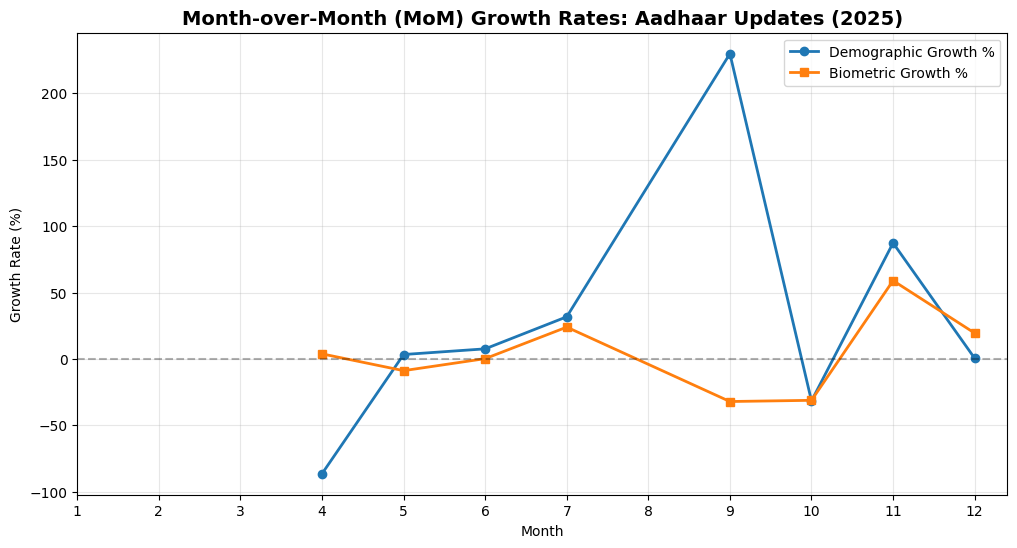

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import save_figure

# Load master data
df_master = pd.read_csv('../data/processed/master_aadhaar_2025.csv')

# Calculate Monthly Totals
monthly_totals = df_master.groupby('month').agg({
    'total_demo_updates': 'sum',
    'total_bio_updates': 'sum'
}).sort_index()

# Calculate MoM Growth Rate (%)
# Formula: (Current - Previous) / Previous * 100
mom_growth = monthly_totals.pct_change() * 100

plt.figure(figsize=(12, 6))
plt.plot(mom_growth.index, mom_growth['total_demo_updates'], marker='o', label='Demographic Growth %', linewidth=2, color='#1f77b4')
plt.plot(mom_growth.index, mom_growth['total_bio_updates'], marker='s', label='Biometric Growth %', linewidth=2, color='#ff7f0e')

plt.axhline(0, color='black', linestyle='--', alpha=0.3) # Zero line for reference
plt.title('Month-over-Month (MoM) Growth Rates: Aadhaar Updates (2025)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Growth Rate (%)')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True, alpha=0.3)

save_figure(plt.gcf(), '08_mom_growth_rates')
plt.show()

Saved figure to c:\Users\Asus\Documents\UIDAI Data Hackathon 2026\reports\figures\09_infant_state_month_heatmap_20260407_032915.png


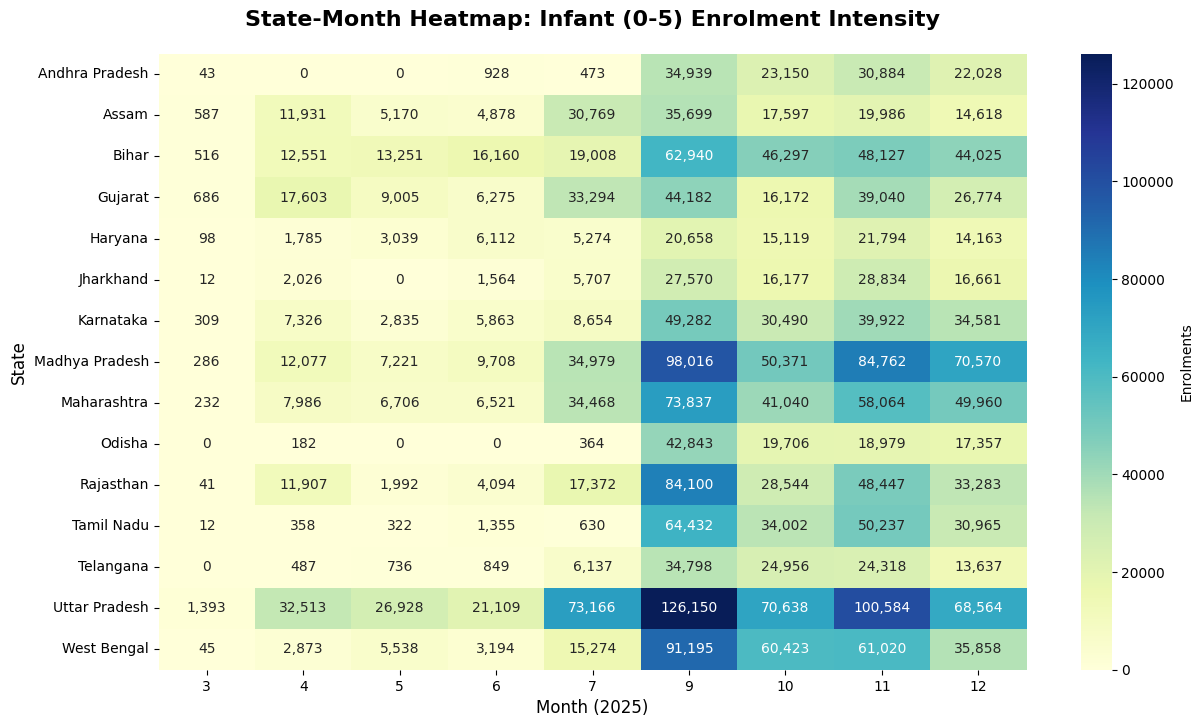

In [3]:
# Focus on Top 15 states for readability
top_15_states = df_master.groupby('state')['age_0_5'].sum().nlargest(15).index
df_subset = df_master[df_master['state'].isin(top_15_states)]

# Pivot table: Index=State, Columns=Month, Values=Sum of age_0_5
pivot_infants = df_subset.pivot_table(index='state', columns='month', values='age_0_5', aggfunc='sum')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_infants, annot=True, fmt=',.0f', cmap='YlGnBu', cbar_kws={'label': 'Enrolments'})
plt.title('State-Month Heatmap: Infant (0-5) Enrolment Intensity', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month (2025)', fontsize=12)
plt.ylabel('State', fontsize=12)

save_figure(plt.gcf(), '09_infant_state_month_heatmap')
plt.show()